# VIS Detection Comparison: Three Detection Views

This notebook compares one randomly chosen VIS tile across exactly three detection views on the same VIS image:
1. **Classical VIS** source finding at native Euclid VIS resolution
2. **Round-2 V7 + CenterNet** detections
3. **Round-2 V7 + StemCenterNet** detections

Important note:
- This notebook does **not** treat the classical VIS detector as ground truth.
- The goal is to see all three detection sets together on the same tile and inspect where the neural models agree, differ, or go beyond the classical baseline.


In [13]:
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in [start, *start.parents]:
        if (cand / 'models').exists() and (cand / 'data').exists():
            return cand
    raise FileNotFoundError('Could not find repo root containing models/ and data/.')


REPO = find_repo_root()
MODELS = REPO / 'models'
for path in [MODELS, MODELS / 'detection', MODELS / 'astrometry2']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from jaisp_foundation_v7 import JAISPFoundationV7
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector
from detection.dataset import _pseudo_labels_vis

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Repo root: {REPO}')
print(f'Device: {DEVICE}')


def safe_rms_from_var(var: np.ndarray) -> np.ndarray:
    var = np.asarray(var, dtype=np.float32)
    good = np.isfinite(var) & (var > 0) & (var < 1e20)
    fallback = float(np.sqrt(np.median(var[good]))) if good.any() else 1.0
    out = np.full(var.shape, fallback, dtype=np.float32)
    out[good] = np.sqrt(var[good])
    return out


def to_tensor_1chw(arr: np.ndarray, device: torch.device) -> torch.Tensor:
    arr = np.asarray(arr, dtype=np.float32)
    return torch.from_numpy(arr[None, None]).to(device)


def pick_random_tile_name(rubin_dir: Path, euclid_dir: Path, seed: Optional[int] = None) -> str:
    rubin_stems = sorted(p.stem for p in rubin_dir.glob('tile_x*_y*.npz'))
    shared = [stem for stem in rubin_stems if (euclid_dir / f'{stem}_euclid.npz').exists()]
    if not shared:
        raise RuntimeError('No shared Rubin/Euclid tiles found in the selected directories.')
    rng = np.random.default_rng(seed)
    return str(rng.choice(shared))


def vis_centroids_to_xy(centroids_norm: np.ndarray, hw: tuple[int, int]) -> np.ndarray:
    h, w = hw
    if len(centroids_norm) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    return np.stack([
        centroids_norm[:, 0] * max(w - 1, 1),
        centroids_norm[:, 1] * max(h - 1, 1),
    ], axis=1).astype(np.float32)


def stretch_image(img: np.ndarray, lo: float = 1.0, hi: float = 99.5) -> np.ndarray:
    img = np.asarray(img, dtype=np.float32)
    finite = np.isfinite(img)
    if not finite.any():
        return np.zeros_like(img, dtype=np.float32)
    vals = img[finite]
    vmin, vmax = np.percentile(vals, [lo, hi])
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return np.clip((np.nan_to_num(img, nan=vmin) - vmin) / (vmax - vmin), 0.0, 1.0)


def load_v7_foundation(ckpt_path: Path, device: torch.device) -> JAISPFoundationV7:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    cfg = ckpt.get('config', {})
    foundation = JAISPFoundationV7(
        band_names=cfg.get('band_names'),
        stem_ch=cfg.get('stem_ch', 64),
        hidden_ch=cfg.get('hidden_ch', 256),
        blocks_per_stage=cfg.get('blocks_per_stage', 2),
        transformer_depth=cfg.get('transformer_depth', 4),
        transformer_heads=cfg.get('transformer_heads', 8),
        fused_pixel_scale_arcsec=cfg.get('fused_pixel_scale_arcsec', 0.8),
    )
    foundation.load_state_dict(ckpt['model'], strict=False)
    return foundation.to(device).eval()


def load_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> CenterNetDetector:
    foundation = load_v7_foundation(foundation_ckpt, device)
    encoder = JAISPEncoderWrapper(foundation, freeze=True).to(device)
    detector = CenterNetDetector.load(str(detector_ckpt), encoder=encoder, device=device)
    return detector.eval()


def load_stem_centernet_detector(foundation_ckpt: Path, detector_ckpt: Path, device: torch.device) -> StemCenterNetDetector:
    foundation = load_v7_foundation(foundation_ckpt, device)
    detector = StemCenterNetDetector.load(str(detector_ckpt), foundation, device=device)
    return detector.eval()


def load_tile_pair(stem: str, rubin_dir: Path, euclid_dir: Path, device: torch.device) -> dict:
    rubin_path = rubin_dir / f'{stem}.npz'
    euclid_path = euclid_dir / f'{stem}_euclid.npz'
    if not rubin_path.exists():
        raise FileNotFoundError(rubin_path)
    if not euclid_path.exists():
        raise FileNotFoundError(euclid_path)

    r = np.load(rubin_path, allow_pickle=True)
    e = np.load(euclid_path, allow_pickle=True)

    rubin_img = np.nan_to_num(np.asarray(r['img'], dtype=np.float32), nan=0.0)
    rubin_var = np.asarray(r['var'], dtype=np.float32)
    rubin_rms = np.stack([safe_rms_from_var(v) for v in rubin_var], axis=0)

    vis_img = np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0)
    vis_hw = tuple(vis_img.shape)

    images = {
        'rubin_u': to_tensor_1chw(rubin_img[0], device),
        'rubin_g': to_tensor_1chw(rubin_img[1], device),
        'rubin_r': to_tensor_1chw(rubin_img[2], device),
        'rubin_i': to_tensor_1chw(rubin_img[3], device),
        'rubin_z': to_tensor_1chw(rubin_img[4], device),
        'rubin_y': to_tensor_1chw(rubin_img[5], device),
        'euclid_VIS': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_VIS'], dtype=np.float32), nan=0.0), device),
        'euclid_Y': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_Y'], dtype=np.float32), nan=0.0), device),
        'euclid_J': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_J'], dtype=np.float32), nan=0.0), device),
        'euclid_H': to_tensor_1chw(np.nan_to_num(np.asarray(e['img_H'], dtype=np.float32), nan=0.0), device),
    }
    rms = {
        'rubin_u': to_tensor_1chw(rubin_rms[0], device),
        'rubin_g': to_tensor_1chw(rubin_rms[1], device),
        'rubin_r': to_tensor_1chw(rubin_rms[2], device),
        'rubin_i': to_tensor_1chw(rubin_rms[3], device),
        'rubin_z': to_tensor_1chw(rubin_rms[4], device),
        'rubin_y': to_tensor_1chw(rubin_rms[5], device),
        'euclid_VIS': to_tensor_1chw(safe_rms_from_var(e['var_VIS']), device),
        'euclid_Y': to_tensor_1chw(safe_rms_from_var(e['var_Y']), device),
        'euclid_J': to_tensor_1chw(safe_rms_from_var(e['var_J']), device),
        'euclid_H': to_tensor_1chw(safe_rms_from_var(e['var_H']), device),
    }

    return {
        'stem': stem,
        'rubin_path': rubin_path,
        'euclid_path': euclid_path,
        'vis_img': vis_img,
        'vis_hw': vis_hw,
        'images': images,
        'rms': rms,
    }


def run_detector(detector, images: dict, rms: dict, tile_hw: tuple[int, int], conf_threshold: float) -> tuple[np.ndarray, np.ndarray]:
    with torch.no_grad():
        pred = detector.predict(images, rms, conf_threshold=conf_threshold, tile_hw=tile_hw)
    xy = pred['positions_px'].detach().cpu().numpy().astype(np.float32)
    scores = pred['scores'].detach().cpu().numpy().astype(np.float32)
    return xy, scores


Repo root: /home/shemmati/Work/Projects/JAISP
Device: cuda


In [14]:
RUBIN_DIR = REPO / 'data' / 'rubin_tiles_patch25_box16'
EUCLID_DIR = REPO / 'data' / 'euclid_tiles_patch25_box16'
FOUNDATION_CKPT = REPO / 'checkpoints' / 'jaisp_v7_tiles_all_ddp_online' / 'checkpoint_best.pt'
CENTERNET_ROUND2_CKPT = REPO / 'checkpoints' / 'centernet_v7_patch25_box16_round2' / 'centernet_best.pt'
STEM_CENTERNET_ROUND2_CKPT = REPO / 'checkpoints' / 'stem_centernet_v7_patch25_box16_round2' / 'stem_centernet_best.pt'

RANDOM_TILE_SEED = None
CLASSICAL_VIS_NSIG = 3.0
CENTERNET_CONF_THRESHOLD = 0.30
STEM_CENTERNET_CONF_THRESHOLD = 0.30

assert RUBIN_DIR.exists(), RUBIN_DIR
assert EUCLID_DIR.exists(), EUCLID_DIR
assert FOUNDATION_CKPT.exists(), FOUNDATION_CKPT
assert CENTERNET_ROUND2_CKPT.exists(), CENTERNET_ROUND2_CKPT
assert STEM_CENTERNET_ROUND2_CKPT.exists(), STEM_CENTERNET_ROUND2_CKPT

TILE_NAME = pick_random_tile_name(RUBIN_DIR, EUCLID_DIR, seed=RANDOM_TILE_SEED)
print(f'Random tile: {TILE_NAME}')
print(f'CenterNet round2: {CENTERNET_ROUND2_CKPT}')
print(f'StemCenterNet round2: {STEM_CENTERNET_ROUND2_CKPT}')


Random tile: tile_x00000_y00000_tract5063_patch_25
CenterNet round2: /home/shemmati/Work/Projects/JAISP/checkpoints/centernet_v7_patch25_box16_round2/centernet_best.pt
StemCenterNet round2: /home/shemmati/Work/Projects/JAISP/checkpoints/stem_centernet_v7_patch25_box16_round2/stem_centernet_best.pt


In [15]:
tile = load_tile_pair(TILE_NAME, RUBIN_DIR, EUCLID_DIR, DEVICE)
centernet = load_centernet_detector(FOUNDATION_CKPT, CENTERNET_ROUND2_CKPT, DEVICE)
stem_centernet = load_stem_centernet_detector(FOUNDATION_CKPT, STEM_CENTERNET_ROUND2_CKPT, DEVICE)

vis_centroids_norm, _, _, _ = _pseudo_labels_vis(tile['vis_img'], nsig=CLASSICAL_VIS_NSIG, max_sources=1000)
vis_classical_xy = vis_centroids_to_xy(vis_centroids_norm, tile['vis_hw'])

centernet_xy, centernet_scores = run_detector(
    centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    CENTERNET_CONF_THRESHOLD,
)
stem_xy, stem_scores = run_detector(
    stem_centernet,
    tile['images'],
    tile['rms'],
    tile['vis_hw'],
    STEM_CENTERNET_CONF_THRESHOLD,
)

print(tile['euclid_path'].name)
print(f'VIS classical detections: {len(vis_classical_xy)}')
print(f'Round-2 V7 + CenterNet detections: {len(centernet_xy)}')
print(f'Round-2 V7 + StemCenterNet detections: {len(stem_xy)}')
print(f'CenterNet median score: {np.median(centernet_scores):.3f}' if len(centernet_scores) else 'CenterNet median score: n/a')
print(f'StemCenterNet median score: {np.median(stem_scores):.3f}' if len(stem_scores) else 'StemCenterNet median score: n/a')


JAISPFoundationV7: 16.0M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.80"/px
JAISPFoundationV7: 16.0M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.80"/px
tile_x00000_y00000_tract5063_patch_25_euclid.npz
VIS classical detections: 264
Round-2 V7 + CenterNet detections: 258
Round-2 V7 + StemCenterNet detections: 274
CenterNet median score: 0.569
StemCenterNet median score: 0.897


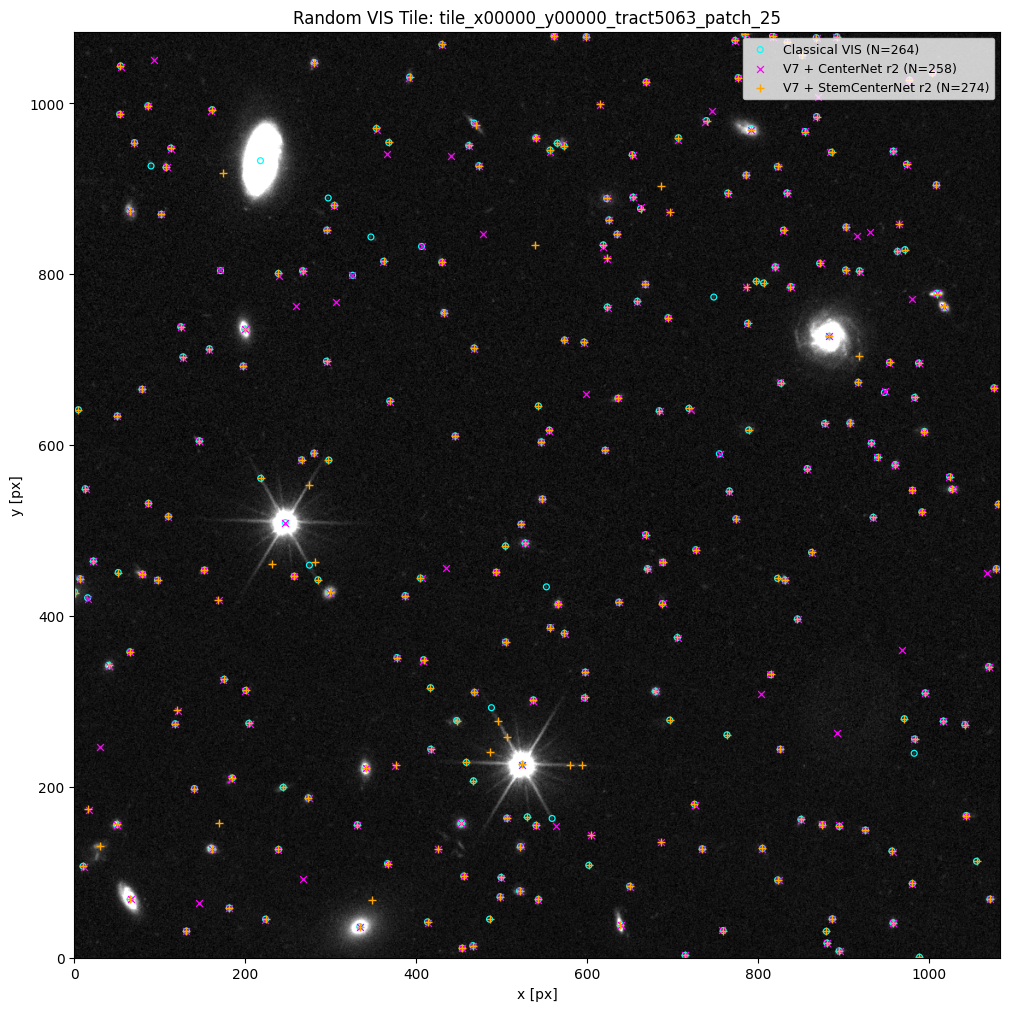

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

ax.imshow(stretch_image(tile['vis_img']), cmap='gray', origin='lower')

if len(vis_classical_xy):
    ax.scatter(
        vis_classical_xy[:, 0],
        vis_classical_xy[:, 1],
        s=18,
        facecolors='none',
        edgecolors='cyan',
        linewidths=0.9,
        marker='o',
        label=f'Classical VIS (N={len(vis_classical_xy)})',
    )

if len(centernet_xy):
    ax.scatter(
        centernet_xy[:, 0],
        centernet_xy[:, 1],
        s=24,
        c='magenta',
        marker='x',
        linewidths=0.9,
        label=f'V7 + CenterNet r2 (N={len(centernet_xy)})',
    )

if len(stem_xy):
    ax.scatter(
        stem_xy[:, 0],
        stem_xy[:, 1],
        s=28,
        c='orange',
        marker='+',
        linewidths=1.0,
        label=f'V7 + StemCenterNet r2 (N={len(stem_xy)})',
    )

ax.set_title(f'Random VIS Tile: {tile["stem"]}')
ax.set_xlim(0, tile['vis_hw'][1])
ax.set_ylim(0, tile['vis_hw'][0])
ax.set_xlabel('x [px]')
ax.set_ylabel('y [px]')
ax.legend(loc='upper right', fontsize=9)
plt.show()
